In [56]:
import sys
sys.path.append('../src')
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

import numpy as np
import jax
import jax.numpy as jnp
import mrcfile
import matplotlib.pyplot as plt
from pinn.cryoet_io import open_raw_data
from pinn.plot import (
    visualize_checkpoint_level_set,
    visualize_checkpoint_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history, initial_loss
from pinn.model import (
    PINN,
    WEIGHT_IN, 
    EPSILON,
    LEARNING_RATE
) 
from pinn.checkpoint_io import (
    _ensure_dir,
    save_params_bytes,
    load_state_bytes,
    save_loss_npz,
    load_loss_npz,
    find_last_state_path
)
from pinn.checkpoint_io import load_checkpoint_at_step
from pinn.train import create_train_state, train_step
from pinn.grid import phi_on_cryo_grid_xyz
from pinn.plot import _to_zyx, visualize_zyx_midslice, visualize_zyx_midslice_vs_overlay

In [57]:
data_dir = "VLP_Cropped"
shape = "62_normalized_preprocessed_2"
mask_shape = "74_S1_mask"
mrc_file_path = f"../data/{data_dir}/{shape}.mrc"
sdf_pretrain = "sphere"

with mrcfile.open(mrc_file_path, permissive=True) as mrc:
    data = np.asarray(mrc.data, dtype=np.float32)

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import find_contours

# ----------------------------------------
# helper: analyze single z-slice
# ----------------------------------------
def analyze_slice_from_contours(
    phi_slice,
    z_index=None,
    debug_plot=False,
    min_points=20,
    close_thresh=2.0
):
    """
    return:
        num_components
        circularities (list)
        centers (list of (x,y))
        mean_center_dist   # float or np.nan
    """

    contours = find_contours(phi_slice, level=0.0)

    num_components = 0
    circularities = []
    centers = []

    # ======================
    # process each contour
    # ======================
    for c in contours:
        if c.shape[0] < min_points:
            continue

        # closed contour check
        if np.linalg.norm(c[0] - c[-1]) > close_thresh:
            continue

        num_components += 1

        # area
        y = c[:, 0]
        x = c[:, 1]
        area = 0.5 * np.abs(np.dot(x, np.roll(y, -1)) -
                            np.dot(y, np.roll(x, -1)))

        # perimeter
        diffs = np.diff(c, axis=0)
        perim = np.sum(np.linalg.norm(diffs, axis=1))

        if perim > 0 and area > 0:
            circ = 4*np.pi*area / (perim**2)
            circularities.append(circ)

        # centroid
        cx = np.mean(c[:, 1])
        cy = np.mean(c[:, 0])
        centers.append((cx, cy))

    # ---------------------------------
    # compute mean center distance
    # ---------------------------------
    if len(centers) <= 1:
        mean_center_dist = np.nan
    else:
        centers = np.array(centers)
        sum_dist = 0.0
        count = 0
        for i in range(len(centers)):
            for j in range(i+1, len(centers)):
                sum_dist += np.linalg.norm(centers[i] - centers[j])
                count += 1
        mean_center_dist = sum_dist / count if count > 0 else np.nan

    # ----------------------------------
    # debug plotting
    # ----------------------------------
    if debug_plot:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.imshow(phi_slice, cmap='gray')

        # draw contours
        for c in contours:
            ax.plot(c[:, 1], c[:, 0], color='red', linewidth=1.0)

        # draw centers
        for (cx, cy) in centers:
            ax.plot(cx, cy, 'yo')

        # build improved title
        mean_circ = np.nan if len(circularities) == 0 else np.mean(circularities)
        title = f"z={z_index} | comps={num_components}"
        title += f" | mean circ={mean_circ:.3f}" if not np.isnan(mean_circ) else ""
        title += f" | mean center-dist={mean_center_dist:.2f}" if not np.isnan(mean_center_dist) else ""

        ax.set_title(title)
        ax.set_axis_off()
        plt.tight_layout()
        plt.show()

    return num_components, circularities, centers, mean_center_dist


In [59]:
import re

# # lambda ranges
# lambda2_values = np.arange(0, 2001, 100)          # 0, 100, ..., 2000
# lambda1_values = list(np.logspace(4, 8, num=20))  # 1e4 ~ 1e8
step = 10000

base_dir = f"../outputs/logs/{shape}"

folders = [d for d in os.listdir(base_dir) if d.startswith("lambda_")]

lambda_pairs = []   # list of (lambda1, lambda2, full_path)
lambda1_list = []
lambda2_list = []

for d in folders:
    # example name:
    # lambda_5455594.781168515_0_weightIn_0.5_epsilon_...
    m = re.match(r"lambda_([0-9\.eE+-]+)_([0-9\.eE+-]+)_", d)
    if m:
        lambda1 = float(m.group(1))
        lambda2 = int(m.group(2))
        lambda_pairs.append((lambda1, lambda2, os.path.join(base_dir, d)))
        lambda1_list.append(lambda1)
        lambda2_list.append(lambda2)

# sort for nicer sweeps
lambda1_unique = np.array(sorted(set(lambda1_list)))
lambda2_unique = np.array(sorted(set(lambda2_list)))
lambda_pairs.sort(key=lambda x: (x[1], x[0]))

In [60]:
def index_of(value, arr):
    # arr is sorted
    return np.where(arr == value)[0][0]

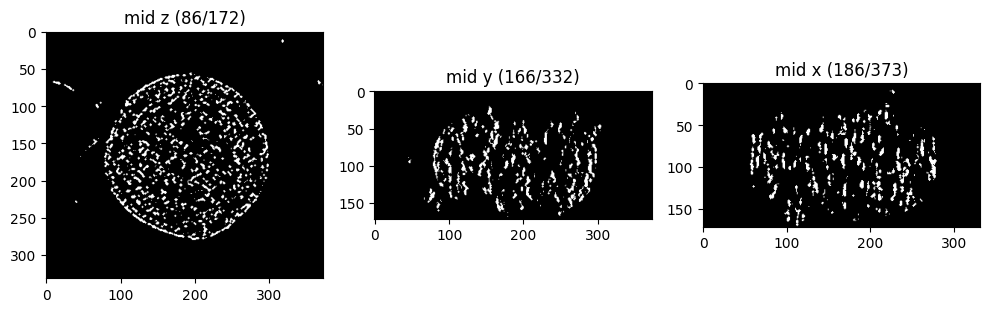

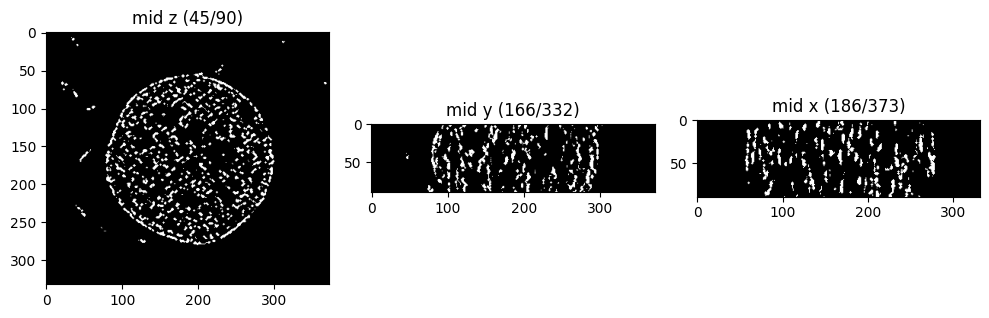

In [61]:
visualize_zyx_midslice(data, None)
data_cropped = data[50:140,:,:]
visualize_zyx_midslice(data_cropped, None)

In [ ]:
L1, L2 = np.meshgrid(lambda1_unique, lambda2_unique)

avg_circularity = np.full(L1.shape, np.nan)
avg_num_components = np.full(L1.shape, np.nan)
avg_center_distance = np.full(L1.shape, np.nan)

for lambda_1, lambda_2, folder in lambda_pairs:
        print(f"Running λ₁ = {lambda_1:.3e}, λ₂ = {lambda_2:.3e}")

        checkpoint_dir = os.path.abspath(
            f"../outputs/logs/{shape}/"
            f"lambda_{lambda_1}_{lambda_2}_weightIn_{0.5}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}/checkpoint"
        )
        print("  checkpoint_dir:", checkpoint_dir)

        try:
            checkpoint_data = load_checkpoint_at_step(step, checkpoint_dir, lambda_1, lambda_2)
        except FileNotFoundError:
            print("  -> checkpoint not found, skip")
            continue

        state = checkpoint_data["state"]
        params = state["params"]
        model = PINN()

        phi_fn = lambda x: model.apply(params, x.reshape(-1, 3))
        phi_xyz, _, (x_axis, y_axis, z_axis) = phi_on_cryo_grid_xyz(
            phi_fn, data.shape, lo=-1.0, hi=1.0
        )
        phi_zyx = _to_zyx(np.array(phi_xyz))
        phi_zyx = phi_zyx[50:140,:,:]       # Cropping

        # zslices = data.shape[0]
        zslices = data_cropped.shape[0]

        slice_num_components = []
        slice_circularities = []
        slice_center_dists = []

        for z in range(zslices):
            phi_slice = phi_zyx[z]

            num_components, circularities, centers, mean_center_dist = analyze_slice_from_contours(
                phi_slice,
                z_index=z,
                debug_plot=False,        # 필요하면 True로
                min_points=20,
                close_thresh=2.0,
            )

            if num_components > 0:
                slice_num_components.append(num_components)
                slice_circularities.extend(circularities)
                if not np.isnan(mean_center_dist):
                    slice_center_dists.append(mean_center_dist)
        
        # 평균 저장
        i_l2 = index_of(lambda_2, lambda2_unique)
        j_l1 = index_of(lambda_1, lambda1_unique)

        if slice_num_components:
            avg_num_components[i_l2, j_l1] = np.mean(slice_num_components)

        if slice_circularities:
            avg_circularity[i_l2, j_l1] = np.mean(slice_circularities)

        if slice_center_dists:
            avg_center_distance[i_l2, j_l1] = np.mean(slice_center_dists)

Running λ₁ = 1.000e+04, λ₂ = 0.000e+00
  checkpoint_dir: /home/minisemin/matsulab/pinn-exploration-model/outputs/logs/62_normalized_preprocessed_2/lambda_10000.0_0_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint
Running λ₁ = 1.624e+04, λ₂ = 0.000e+00
  checkpoint_dir: /home/minisemin/matsulab/pinn-exploration-model/outputs/logs/62_normalized_preprocessed_2/lambda_16237.76739188721_0_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint
Running λ₁ = 2.637e+04, λ₂ = 0.000e+00
  checkpoint_dir: /home/minisemin/matsulab/pinn-exploration-model/outputs/logs/62_normalized_preprocessed_2/lambda_26366.508987303554_0_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint
Running λ₁ = 4.281e+04, λ₂ = 0.000e+00
  checkpoint_dir: /home/minisemin/matsulab/pinn-exploration-model/outputs/logs/62_normalized_preprocessed_2/lambda_42813.32398719396_0_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint
Running λ₁ = 6.952e+04, λ₂ = 0.000e+00
  checkpoint_dir: /home/minisemin/matsulab/pinn-exploration-model/

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

###############################################
# Helper: colormap with NaN as light gray
###############################################
def cmap_with_nan(base_cmap="viridis", nan_color="lightgray"):
    base = plt.cm.get_cmap(base_cmap)
    colors = base(np.arange(base.N))
    new_cmap = ListedColormap(colors)
    new_cmap.set_bad(color=nan_color)
    return new_cmap

###############################################
# 4th plot: calculate val
###############################################
min_val = np.nanmin(avg_center_distance)
max_val = np.nanmax(avg_center_distance)

inverted_avg_center_distance = 1 - (avg_center_distance - min_val) / (max_val - min_val)

val = (avg_num_components / 4) * avg_circularity * inverted_avg_center_distance

###############################################
# Figure & axes (1 x 4)
###############################################
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

################################################
# 1) Avg # of closed contours per z-slice (NaN -> 0)
################################################
comp_data = np.nan_to_num(avg_num_components, nan=0.0)

cs1 = axes[0].contourf(L1, L2, comp_data, levels=5, cmap="viridis")
axes[0].set_xscale('log')
axes[0].set_title("Avg # of closed contours per z-slice", pad=30)
axes[0].set_xlabel(r"$\lambda_1$ (data)")
axes[0].set_ylabel(r"$\lambda_2$ (physics)")
axes[0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.5)
axes[0].scatter(L1.flatten(), L2.flatten(),
                c=comp_data.flatten(),
                cmap='viridis', edgecolor='k', s=20, alpha=0.7)
fig.colorbar(cs1, ax=axes[0])

################################################
# 공통: 나머지 플롯에서 NaN을 light gray로
################################################
cmap_nan = cmap_with_nan("viridis", "lightgray")

################################################
# 2) Avg circularity per z-slice (NaN -> lightgray + No solutions)
################################################
data2 = avg_circularity
cs2 = axes[1].contourf(L1, L2, data2, levels=5, cmap=cmap_nan)
axes[1].set_xscale('log')
axes[1].set_title("Avg circularity per z-slice", pad=30)
axes[1].set_xlabel(r"$\lambda_1$ (data)")
axes[1].set_ylabel(r"$\lambda_2$ (physics)")
axes[1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.5)
axes[1].scatter(L1.flatten(), L2.flatten(),
                c=data2.flatten(),
                cmap='viridis', edgecolor='k', s=20, alpha=0.7)
fig.colorbar(cs2, ax=axes[1])

if np.any(np.isnan(data2)):
    axes[1].text(0.5, 0.5, "No solutions",
                 fontsize=14, color="black",
                 ha="center", va="center",
                 transform=axes[1].transAxes)

################################################
# 3) Avg pairwise center distance (NaN -> lightgray + No solutions)
################################################
data3 = avg_center_distance
cs3 = axes[2].contourf(L1, L2, data3, levels=5, cmap=cmap_nan)
axes[2].set_xscale('log')
axes[2].set_title("Avg pairwise center distance\nbetween contours per z-slice", pad=30)
axes[2].set_xlabel(r"$\lambda_1$ (data)")
axes[2].set_ylabel(r"$\lambda_2$ (physics)")
axes[2].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.5)
axes[2].scatter(L1.flatten(), L2.flatten(),
                c=data3.flatten(),
                cmap='viridis', edgecolor='k', s=20, alpha=0.7)
fig.colorbar(cs3, ax=axes[2])

if np.any(np.isnan(data3)):
    axes[2].text(0.5, 0.5, "No solutions",
                 fontsize=14, color="black",
                 ha="center", va="center",
                 transform=axes[2].transAxes)

################################################
# 4) Combined: components x circularity x inverted distance
#    (NaN -> lightgray + No solutions)
################################################
data4 = val
cs4 = axes[3].contourf(L1, L2, data4, levels=5, cmap=cmap_nan)
axes[3].set_xscale('log')
axes[3].set_title("Avg #components × circularity × distance", pad=30)
axes[3].set_xlabel(r"$\lambda_1$ (data)")
axes[3].set_ylabel(r"$\lambda_2$ (physics)")
axes[3].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.5)
axes[3].scatter(L1.flatten(), L2.flatten(),
                c=data4.flatten(),
                cmap='viridis', edgecolor='k', s=20, alpha=0.7)
fig.colorbar(cs4, ax=axes[3])

if np.any(np.isnan(data4)):
    axes[3].text(0.5, 0.5, "No solutions",
                 fontsize=14, color="black",
                 ha="center", va="center",
                 transform=axes[3].transAxes)

plt.tight_layout()
plt.show()


AttributeError: 'numpy.ndarray' object has no attribute 'contourf'

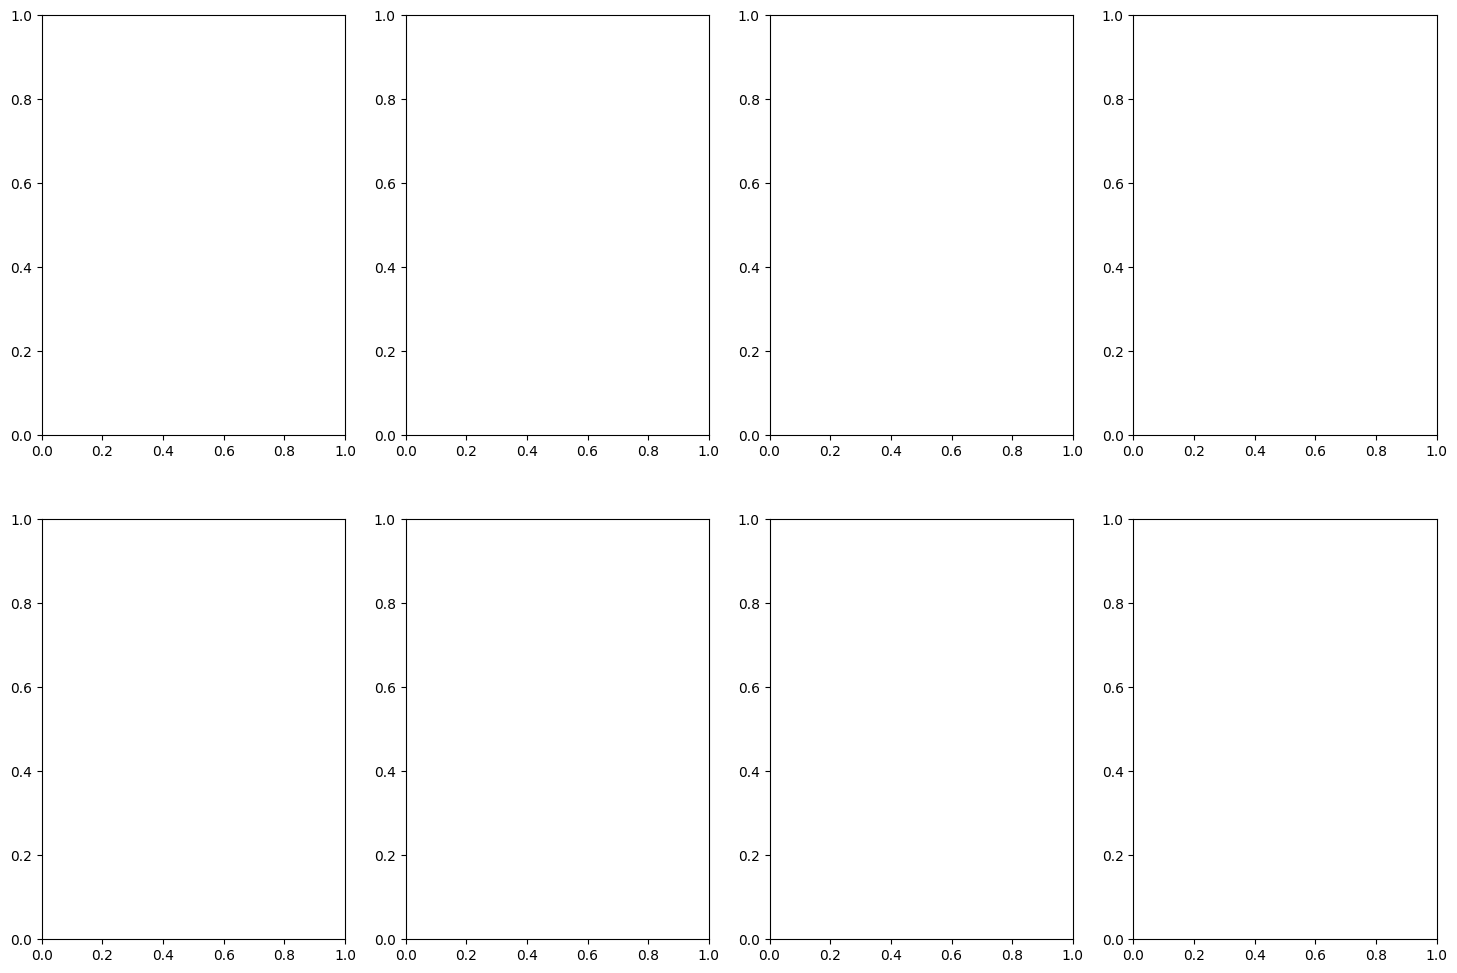

In [55]:
fig, axes = plt.subplots(2, 4, figsize=(18, 12))

# 1) components
cs1 = axes[0].contourf(L1, L2, avg_num_components, levels=5)
axes[0].set_xscale('log')
axes[0].set_title("Avg # of closed contours per z-slice", pad=30)
axes[0].set_xlabel(r"$\lambda_1$ (data)")
axes[0].set_ylabel(r"$\lambda_2$ (physics)")
axes[0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.5)
axes[0].scatter(L1.flatten(), L2.flatten(),
                c=avg_num_components.flatten(),
                cmap='viridis', edgecolor='k', s=20, alpha=0.7)
fig.colorbar(cs1, ax=axes[0])

# 2) circularity
cs2 = axes[1].contourf(L1, L2, avg_circularity, levels=5)
axes[1].set_xscale('log')
axes[1].set_title("Avg circularity per z-slice", pad=30)
axes[1].set_xlabel(r"$\lambda_1$ (data)")
axes[1].set_ylabel(r"$\lambda_2$ (physics)")
axes[1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.5)
axes[1].scatter(L1.flatten(), L2.flatten(),
                c=avg_circularity.flatten(),
                cmap='viridis', edgecolor='k', s=20, alpha=0.7)
fig.colorbar(cs2, ax=axes[1])

# 3) center distance
cs3 = axes[2].contourf(L1, L2, avg_center_distance, levels=5)
axes[2].set_xscale('log')
axes[2].set_title("Avg pairwise center distance between contours per z-slice", pad=30)
axes[2].set_xlabel(r"$\lambda_1$ (data)")
axes[2].set_ylabel(r"$\lambda_2$ (physics)")
axes[2].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.5)
axes[2].scatter(L1.flatten(), L2.flatten(),
                c=avg_center_distance.flatten(),
                cmap='viridis', edgecolor='k', s=20, alpha=0.7)
fig.colorbar(cs3, ax=axes[2])

plt.tight_layout()
plt.show()

In [47]:
print(np.isnan(avg_center_distance).any())
print(np.isinf(avg_center_distance).any())

True
False


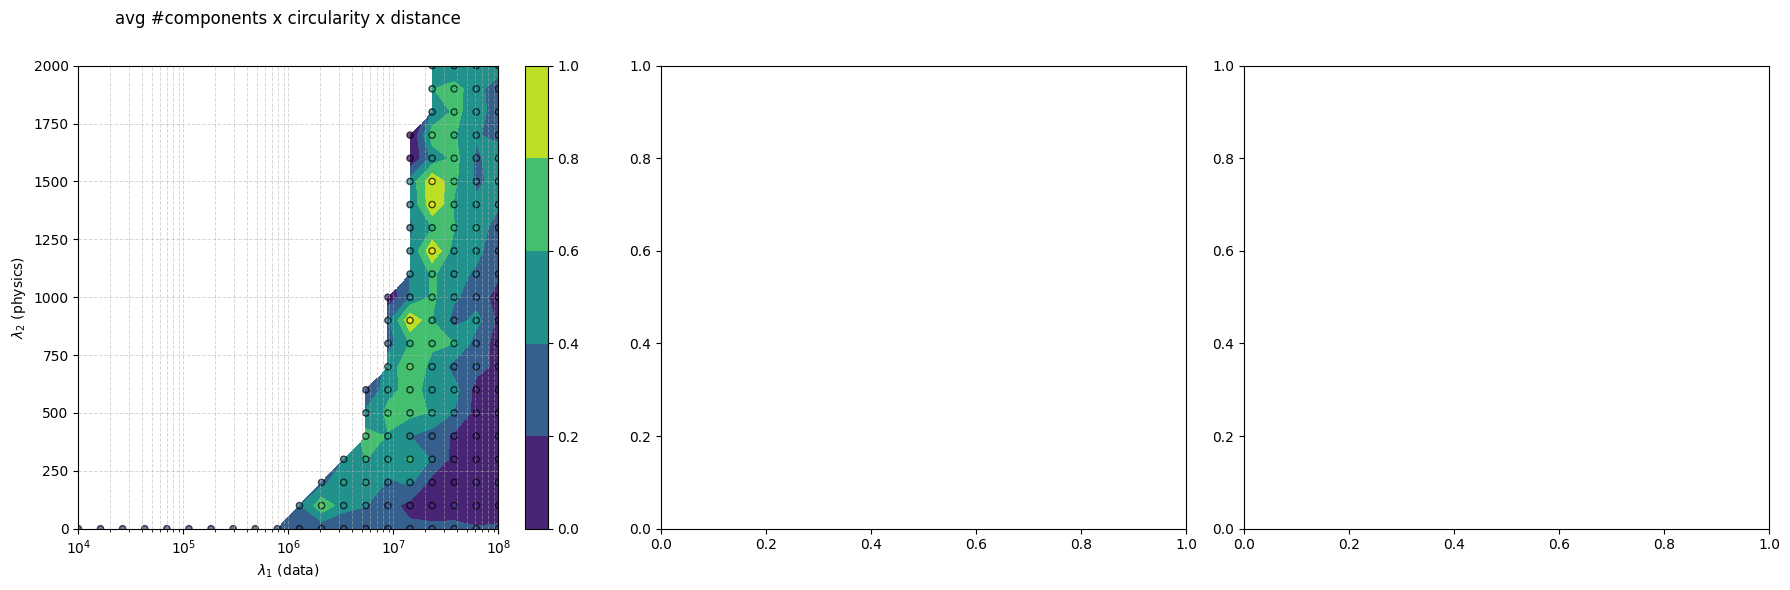

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

min_val = np.nanmin(avg_center_distance)
max_val = np.nanmax(avg_center_distance)

inverted_avg_center_distance = 1 - (avg_center_distance - min_val) / (max_val - min_val)

val = (avg_num_components / 4) * avg_circularity * inverted_avg_center_distance

# 1) components
cs1 = axes[0].contourf(L1, L2, val, levels=5)
axes[0].set_xscale('log')
axes[0].set_title("avg #components x circularity x distance", pad=30)
axes[0].set_xlabel(r"$\lambda_1$ (data)")
axes[0].set_ylabel(r"$\lambda_2$ (physics)")
axes[0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.5)
axes[0].scatter(L1.flatten(), L2.flatten(),
                c=val.flatten(),
                cmap='viridis', edgecolor='k', s=20, alpha=0.7)
fig.colorbar(cs1, ax=axes[0])

plt.tight_layout()
plt.show()

In [24]:
print(avg_num_components)
print(avg_center_distance)
print(avg_circularity)

[[2.06666667 2.23333333 2.21111111 2.12222222 2.24444444 2.23333333
  2.21111111 2.18888889 2.22222222 2.23333333 2.07777778 2.24444444
  2.24444444 2.21111111 2.18888889 2.24444444 2.2        2.2
  2.18888889 2.23333333]
 [       nan        nan        nan        nan        nan        nan
         nan        nan        nan 1.         2.93333333 3.52222222
  2.4        2.3        2.1        1.82222222 2.47777778 2.3
  2.34444444 2.18888889]
 [       nan        nan        nan        nan        nan        nan
         nan        nan        nan        nan 1.         2.5
  2.67777778 2.77777778 2.16666667 2.66666667 1.93333333 2.46666667
  1.96666667 2.58888889]
 [       nan        nan        nan        nan        nan        nan
         nan        nan        nan        nan        nan 1.
  2.4        2.71111111 2.61111111 2.8        2.5        1.9
  2.53333333 2.12222222]
 [       nan        nan        nan        nan        nan        nan
         nan        nan        nan        nan       